### **A-I 574 Natural Language Processing**

**Assignment 5 & 6 Final Comparative Report**

**Objective**: To compare the instructor-provided baseline RNN architecture against progressively improved models, culminating in a Bi-directional GRU (BiGRU) with Masked Mean-Max Pooling for language detection on the Tatoeba dataset.

##### ***Initial Settings***

In [20]:
# Importing the Required Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Use Apple Metal GPU if available, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


##### ***Loading, Exploring, and Preprocessing the Dataset***

In [21]:
# Loading the datasets
data_path = '/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/week3/tatoeba/'
train_df = pd.read_csv(data_path + 'sentences.top10langs.train.tsv', sep='\t', header=None)
dev_df = pd.read_csv(data_path + 'sentences.top10langs.dev.tsv', sep='\t', header=None)

# Rename columns for clarity
train_df.columns = ['lang', 'sentence']
dev_df.columns = ['lang', 'sentence']

display(train_df.head())

,lang,sentence
0,spa,"Te di mi corazón para que lo ames, ¡no para us..."
1,spa,Contamos con tu ayuda.
2,spa,Tú eres superficial y materialista.
3,spa,Los límites son para los demás.
4,spa,Todos ellos esperaron ansiosamente las vacacio...


In [22]:
# Encode Labels
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['lang'])
dev_df['label'] = label_encoder.transform(dev_df['lang'])
num_classes = len(label_encoder.classes_)
print(f"Classes: {label_encoder.classes_}")

Classes: ['ber' 'deu' 'eng' 'epo' 'fra' 'hun' 'ita' 'por' 'spa' 'tur']


##### ***Custom PyTorch Dataset and Tokenization***

In [23]:
# Character-level vocabulary
chars = set("".join(train_df['sentence'].values))
vocab = {ch: i+2 for i, ch in enumerate(chars)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
vocab_size = len(vocab)
MAX_LEN = 128

def encode_text(text):
    text_chars = list(text)[:MAX_LEN]
    encoded = [vocab.get(ch, 1) for ch in text_chars]
    length = len(encoded)
    encoded = encoded + [0] * max(0, MAX_LEN - len(encoded))
    return encoded, length

class TatoebaDataset(Dataset):
    def __init__(self, df):
        self.sentences = df['sentence'].values
        self.labels = df['label'].values
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        encoded, length = encode_text(self.sentences[idx])
        return {
            'input_ids': torch.tensor(encoded, dtype=torch.long),
            'length': torch.tensor(length, dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

batch_size = 256
train_dataset = TatoebaDataset(train_df)
dev_dataset = TatoebaDataset(dev_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

##### ***Reusable Training and Evaluation Functions***

In [24]:
def model_fit(model, train_loader, dev_loader, epochs=5, lr=0.001):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    
    best_val_acc = 0
    patience_counter = 0
    patience = 2
    
    for epoch in range(epochs):
        start = time.time()
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        for i, batch in enumerate(train_loader):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            lengths = batch['length'].to(device)
            labels = batch['label'].to(device)
            
            try:
                logits = model(input_ids, lengths)
            except TypeError:
                logits = model(input_ids)
                
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        train_acc = correct / total
        train_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in dev_loader:
                input_ids = batch['input_ids'].to(device)
                lengths = batch['length'].to(device)
                labels = batch['label'].to(device)
                
                try:
                    logits = model(input_ids, lengths)
                except TypeError:
                    logits = model(input_ids)
                    
                loss = criterion(logits, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(dev_loader)
        
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | {time.time()-start:.0f}s - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
                
    model.load_state_dict(torch.load('best_model.pt', weights_only=True))
    return history

def plot_accuracy(history, name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f"{name} - Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', marker='o')
    plt.title(f"{name} - Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dev_loader, name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch['input_ids'].to(device)
            lengths = batch['length'].to(device)
            try:
                logits = model(input_ids, lengths)
            except TypeError:
                logits = model(input_ids)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Trainable Params: {params:,}")
    return {"Model": name, "Accuracy": acc, "Macro F1": f1, "Parameters": params}

results = []

### **Comparative Analysis Workflow**

In this report, we evaluate the performance of various RNN architectures for language detection. We begin with a simple baseline and progressively introduce architectural enhancements to address specific challenges in sequential modeling.

#### **1. Baseline Architecture: Simple RNN**
The Simple RNN is our starting point. It uses a single recurrent layer to process character sequences. While computationally efficient, it often struggles with long-term dependencies due to the vanishing gradient problem.

Epoch 1/5 | 23s - loss: 2.3039 - acc: 0.1015 - val_loss: 2.3015 - val_acc: 0.1001
Epoch 2/5 | 17s - loss: 2.3013 - acc: 0.1022 - val_loss: 2.3012 - val_acc: 0.1016
Epoch 3/5 | 18s - loss: 2.3008 - acc: 0.1014 - val_loss: 2.3000 - val_acc: 0.1023
Epoch 4/5 | 17s - loss: 2.3004 - acc: 0.1012 - val_loss: 2.3008 - val_acc: 0.1027
Epoch 5/5 | 16s - loss: 2.3002 - acc: 0.1031 - val_loss: 2.3037 - val_acc: 0.1025


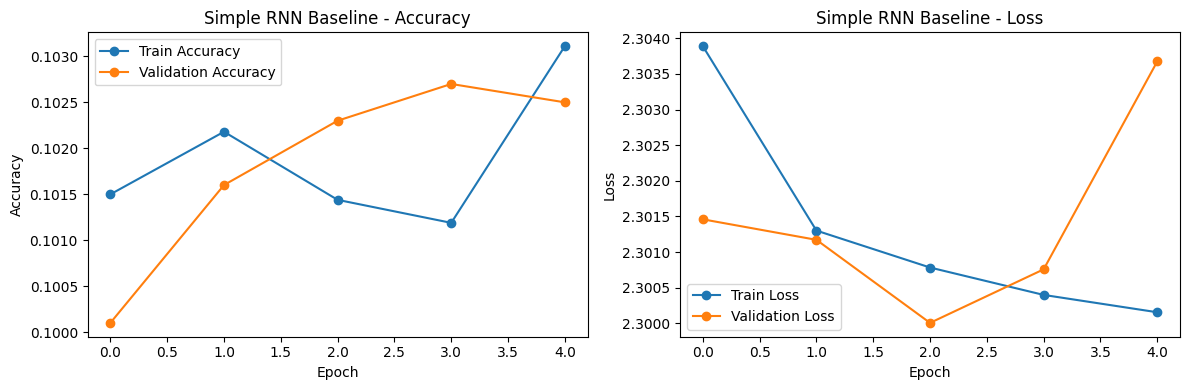

--- Simple RNN Baseline Results ---
Accuracy: 0.1027
Macro F1: 0.0256
Trainable Params: 29,642


In [25]:
class SimpleRNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.rnn = nn.RNN(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x, lengths=None):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model_rnn = SimpleRNNModel()
history_rnn = model_fit(model_rnn, train_loader, dev_loader, epochs=5)
plot_accuracy(history_rnn, "Simple RNN Baseline")
results.append(evaluate_model(model_rnn, dev_loader, "Simple RNN Baseline"))

#### **2. Addressing Vanishing Gradients: LSTM**
The Long Short-Term Memory (LSTM) network introduces a memory cell and gating mechanisms (input, forget, and output gates). These gates allow the model to selectively retain or discard information over long sequences, significantly improving its ability to capture linguistic patterns that span multiple characters.

Epoch 1/5 | 12s - loss: 2.1776 - acc: 0.1385 - val_loss: 1.7933 - val_acc: 0.2280
Epoch 2/5 | 11s - loss: 1.3279 - acc: 0.4447 - val_loss: 0.9483 - val_acc: 0.6294
Epoch 3/5 | 11s - loss: 0.6245 - acc: 0.7663 - val_loss: 0.4966 - val_acc: 0.8149
Epoch 4/5 | 11s - loss: 0.3649 - acc: 0.8598 - val_loss: 0.3344 - val_acc: 0.8853
Epoch 5/5 | 12s - loss: 0.2604 - acc: 0.9105 - val_loss: 0.2259 - val_acc: 0.9315


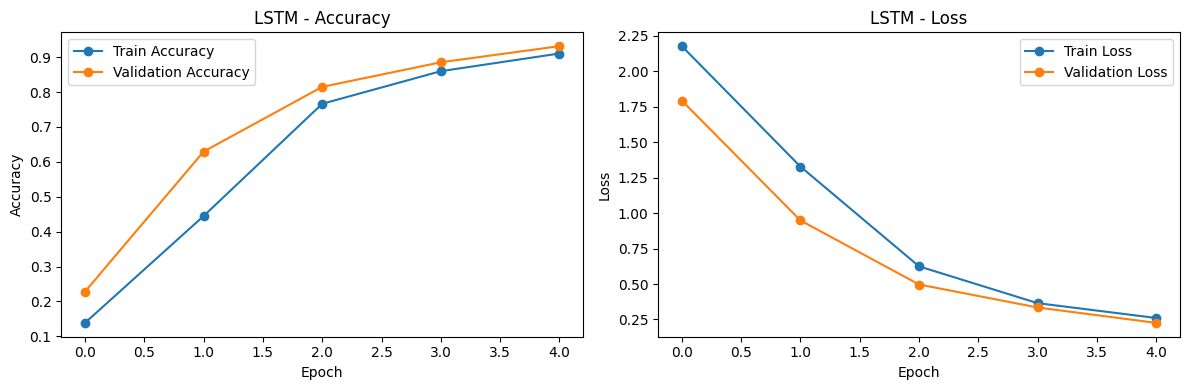

--- LSTM Results ---
Accuracy: 0.9315
Macro F1: 0.9317
Trainable Params: 91,850


In [26]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x, lengths=None):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_lstm = LSTMModel()
history_lstm = model_fit(model_lstm, train_loader, dev_loader, epochs=5)
plot_accuracy(history_lstm, "LSTM")
results.append(evaluate_model(model_lstm, dev_loader, "LSTM"))

#### **3. Capturing Bidirectional Context: BiLSTM**
Language is often context-dependent in both directions. A Bidirectional LSTM (BiLSTM) processes the sequence from left-to-right and right-to-left simultaneously. This allows the model to understand a character's role based on both its preceding and succeeding neighbors.

Epoch 1/5 | 18s - loss: 2.2998 - acc: 0.1042 - val_loss: 2.2644 - val_acc: 0.1479
Epoch 2/5 | 22s - loss: 1.6050 - acc: 0.3046 - val_loss: 1.2538 - val_acc: 0.4003
Epoch 3/5 | 22s - loss: 0.9737 - acc: 0.5530 - val_loss: 0.7976 - val_acc: 0.6311
Epoch 4/5 | 23s - loss: 0.5515 - acc: 0.7826 - val_loss: 0.3962 - val_acc: 0.8656
Epoch 5/5 | 20s - loss: 0.2870 - acc: 0.9035 - val_loss: 0.2153 - val_acc: 0.9299


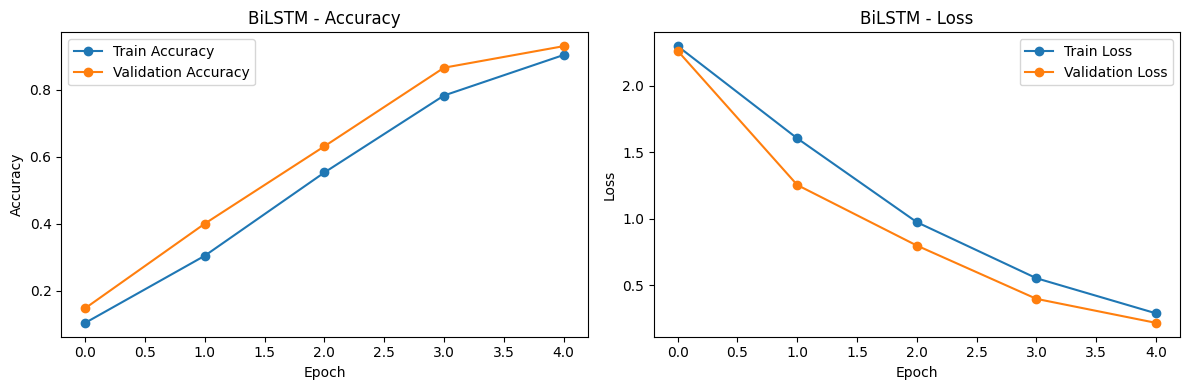

--- BiLSTM Results ---
Accuracy: 0.9299
Macro F1: 0.9302
Trainable Params: 176,074


In [27]:
class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128 * 2, num_classes)
        
    def forward(self, x, lengths=None):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_bilstm = BiLSTMModel()
history_bilstm = model_fit(model_bilstm, train_loader, dev_loader, epochs=5)
plot_accuracy(history_bilstm, "BiLSTM")
results.append(evaluate_model(model_bilstm, dev_loader, "BiLSTM"))

#### **4. Efficiency and Specialized Pooling: Improved BiGRU with Mean-Max Pooling**

The final model introduces two key improvements:
1. **Gated Recurrent Units (GRU)**: A more computationally efficient alternative to LSTM that maintains performance with fewer parameters.
2. **Masked Mean-Max Pooling**: Instead of relying solely on the last hidden state (which can be noisy or dominated by padding in long sequences), we aggregate features across the entire sequence using both average and maximum pooling. Importantly, we apply a mask to ensure that padding tokens do not influence the global representation.

Epoch 1/10 | 469s - loss: 0.3206 - acc: 0.8890 - val_loss: 0.0944 - val_acc: 0.9707
Epoch 2/10 | 461s - loss: 0.0606 - acc: 0.9797 - val_loss: 0.0600 - val_acc: 0.9803
Epoch 3/10 | 456s - loss: 0.0353 - acc: 0.9885 - val_loss: 0.0529 - val_acc: 0.9823
Epoch 4/10 | 396s - loss: 0.0268 - acc: 0.9910 - val_loss: 0.0430 - val_acc: 0.9894
Epoch 5/10 | 401s - loss: 0.0168 - acc: 0.9942 - val_loss: 0.0378 - val_acc: 0.9897
Epoch 6/10 | 379s - loss: 0.0141 - acc: 0.9953 - val_loss: 0.0350 - val_acc: 0.9882
Epoch 7/10 | 381s - loss: 0.0093 - acc: 0.9968 - val_loss: 0.0268 - val_acc: 0.9921
Epoch 8/10 | 376s - loss: 0.0094 - acc: 0.9970 - val_loss: 0.0291 - val_acc: 0.9906
Epoch 9/10 | 375s - loss: 0.0110 - acc: 0.9966 - val_loss: 0.0329 - val_acc: 0.9923
Epoch 10/10 | 370s - loss: 0.0058 - acc: 0.9981 - val_loss: 0.0306 - val_acc: 0.9920


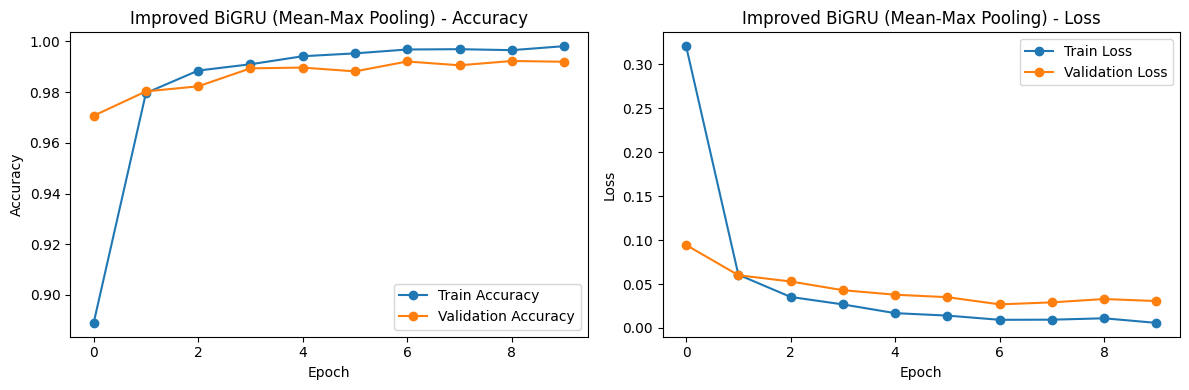

--- Improved BiGRU Results ---
Accuracy: 0.9923
Macro F1: 0.9923
Trainable Params: 1,702,794


In [28]:
class BiGRULanguageID(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_size: int,
        num_layers: int,
        num_classes: int,
        pad_idx: int,
        gru_dropout: float = 0.3,
        classifier_dropout: float = 0.5,
        pooling: str = "mean_max",
    ):
        super().__init__()
        self.pooling = pooling
        self.hidden_size = hidden_size
        self.num_directions = 2

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        rep_dim = hidden_size * self.num_directions
        if pooling == "mean_max":
            rep_dim *= 2

        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(rep_dim, num_classes)

    def masked_mean_pool(self, x, mask):
        mask = mask.unsqueeze(-1).float()
        summed = (x * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-8)
        return summed / denom

    def masked_max_pool(self, x, mask):
        mask = mask.unsqueeze(-1)
        x = x.masked_fill(~mask, -1e9)
        return x.max(dim=1).values

    def forward(self, input_ids, lengths):
        emb = self.embedding(input_ids)
        packed = pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.gru(packed)
        out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=input_ids.size(1),
        )
        time_ids = torch.arange(input_ids.size(1), device=lengths.device).unsqueeze(0)
        mask = time_ids < lengths.unsqueeze(1)
        mean_rep = self.masked_mean_pool(out, mask)
        if self.pooling == "mean":
            rep = mean_rep
        else:
            max_rep = self.masked_max_pool(out, mask)
            rep = torch.cat([mean_rep, max_rep], dim=-1)
        logits = self.classifier(self.dropout(rep))
        return logits

# Initialize and Train the Improved Model
model_bigru = BiGRULanguageID(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_size=256,
    num_layers=2,
    num_classes=num_classes,
    pad_idx=0,
    gru_dropout=0.3,
    classifier_dropout=0.5,
    pooling="mean_max"
)

history_bigru = model_fit(model_bigru, train_loader, dev_loader, epochs=10, lr=0.001)
plot_accuracy(history_bigru, "Improved BiGRU (Mean-Max Pooling)")
results.append(evaluate_model(model_bigru, dev_loader, "Improved BiGRU"))

#### **5. Beyond Recurrence: Transformer Encoder**

The Transformer Encoder replaces the sequential RNN computation with **Multi-Head Self-Attention**, allowing every token to attend to every other token simultaneously. This eliminates the vanishing gradient problem over long sequences and enables full parallelism during training.

**Architecture:**
- **Positional Encoding**: Since transformers have no inherent sense of order, sinusoidal positional encodings are added to the embeddings.
- **Multi-Head Self-Attention + Feed-Forward Layers**: Stacked encoder blocks capture complex character-level patterns.
- **Masked Global Average Pooling**: We pool across all non-padding positions to obtain a fixed-size representation for classification.

Epoch 1/10 | 36s - loss: 0.7522 - acc: 0.7410 - val_loss: 0.3935 - val_acc: 0.8685
Epoch 2/10 | 37s - loss: 0.3644 - acc: 0.8728 - val_loss: 0.3211 - val_acc: 0.8883
Epoch 3/10 | 36s - loss: 0.3148 - acc: 0.8882 - val_loss: 0.2947 - val_acc: 0.8951
Epoch 4/10 | 34s - loss: 0.2871 - acc: 0.8977 - val_loss: 0.2627 - val_acc: 0.9097
Epoch 5/10 | 34s - loss: 0.2698 - acc: 0.9034 - val_loss: 0.2625 - val_acc: 0.9119
Epoch 6/10 | 34s - loss: 0.2554 - acc: 0.9096 - val_loss: 0.2410 - val_acc: 0.9186
Epoch 7/10 | 34s - loss: 0.2422 - acc: 0.9131 - val_loss: 0.2233 - val_acc: 0.9229
Epoch 8/10 | 34s - loss: 0.2324 - acc: 0.9158 - val_loss: 0.2133 - val_acc: 0.9287
Epoch 9/10 | 34s - loss: 0.2231 - acc: 0.9208 - val_loss: 0.2199 - val_acc: 0.9282
Epoch 10/10 | 34s - loss: 0.2154 - acc: 0.9228 - val_loss: 0.2136 - val_acc: 0.9287
Early stopping triggered


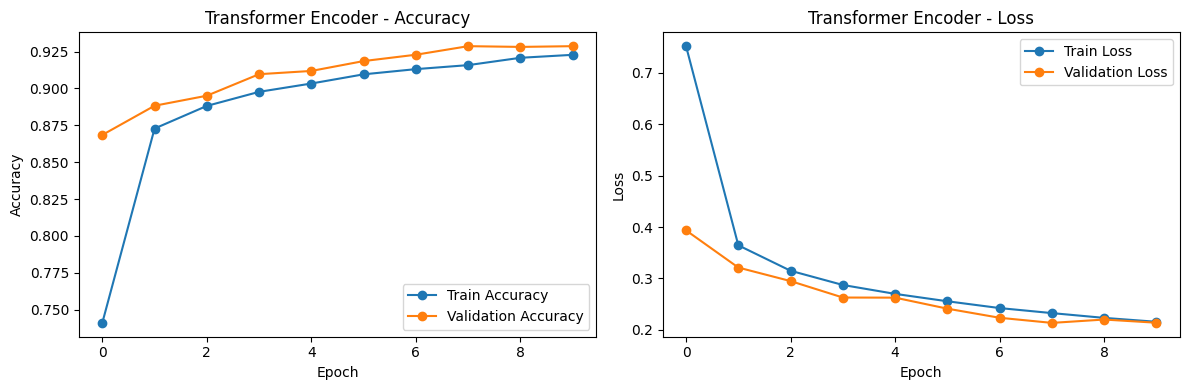

--- Transformer Encoder Results ---
Accuracy: 0.9287
Macro F1: 0.9285
Trainable Params: 115,850


In [29]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.1, num_classes=10, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        # enable_nested_tensor=False disables the fast-path that uses
        # aten::_nested_tensor_from_mask_left_aligned, which is not yet
        # implemented on the MPS (Apple Silicon) backend.
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            enable_nested_tensor=False, mask_check=False
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, lengths=None):
        # Build key padding mask: True = ignore (padding positions)
        if lengths is not None:
            seq_len = input_ids.size(1)
            time_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
            mask = time_ids >= lengths.unsqueeze(1)  # (B, seq_len), True = pad
        else:
            mask = (input_ids == self.pad_idx)

        emb = self.embedding(input_ids)          # (B, T, d_model)
        emb = self.pos_encoder(emb)
        out = self.transformer_encoder(emb, src_key_padding_mask=mask)  # (B, T, d_model)

        # Masked global average pooling (ignore padding)
        non_pad_mask = ~mask                     # (B, T), True = real token
        out = out * non_pad_mask.unsqueeze(-1).float()
        rep = out.sum(dim=1) / non_pad_mask.float().sum(dim=1, keepdim=True).clamp(min=1e-8)

        return self.classifier(rep)

model_transformer_enc = TransformerEncoderClassifier(
    vocab_size=vocab_size, embed_dim=64, nhead=4,
    num_layers=2, dim_feedforward=256, dropout=0.1,
    num_classes=num_classes, pad_idx=0
)
history_transformer_enc = model_fit(model_transformer_enc, train_loader, dev_loader, epochs=10, lr=0.001)
plot_accuracy(history_transformer_enc, "Transformer Encoder")
results.append(evaluate_model(model_transformer_enc, dev_loader, "Transformer Encoder"))

#### **6. Encoder-Decoder Transformer for Classification**

The Encoder-Decoder architecture was originally designed for sequence-to-sequence tasks (e.g., translation). Here, we adapt it for **classification** by using a single learnable `[CLS]` query token in the decoder. The encoder processes the full input sequence and the decoder uses cross-attention to extract a task-relevant summary from the encoder's representations.

**Architecture:**
- **Encoder**: Multi-Head Self-Attention over the full character sequence.
- **Decoder**: A single learned query token attends to the encoder output via cross-attention.
- **Classifier**: The decoder's output token is fed through a linear head.

This is conceptually similar to how BERT uses a `[CLS]` token, but built from scratch.

Epoch 1/10 | 40s - loss: 0.7540 - acc: 0.7365 - val_loss: 0.3707 - val_acc: 0.8704
Epoch 2/10 | 37s - loss: 0.3774 - acc: 0.8680 - val_loss: 0.3009 - val_acc: 0.8940
Epoch 3/10 | 38s - loss: 0.3271 - acc: 0.8841 - val_loss: 0.2623 - val_acc: 0.9095
Epoch 4/10 | 36s - loss: 0.2976 - acc: 0.8941 - val_loss: 0.2504 - val_acc: 0.9152
Epoch 5/10 | 37s - loss: 0.2756 - acc: 0.9024 - val_loss: 0.2351 - val_acc: 0.9195
Epoch 6/10 | 36s - loss: 0.2645 - acc: 0.9046 - val_loss: 0.2174 - val_acc: 0.9253
Epoch 7/10 | 36s - loss: 0.2491 - acc: 0.9114 - val_loss: 0.2343 - val_acc: 0.9146
Epoch 8/10 | 37s - loss: 0.2414 - acc: 0.9130 - val_loss: 0.2121 - val_acc: 0.9252
Early stopping triggered


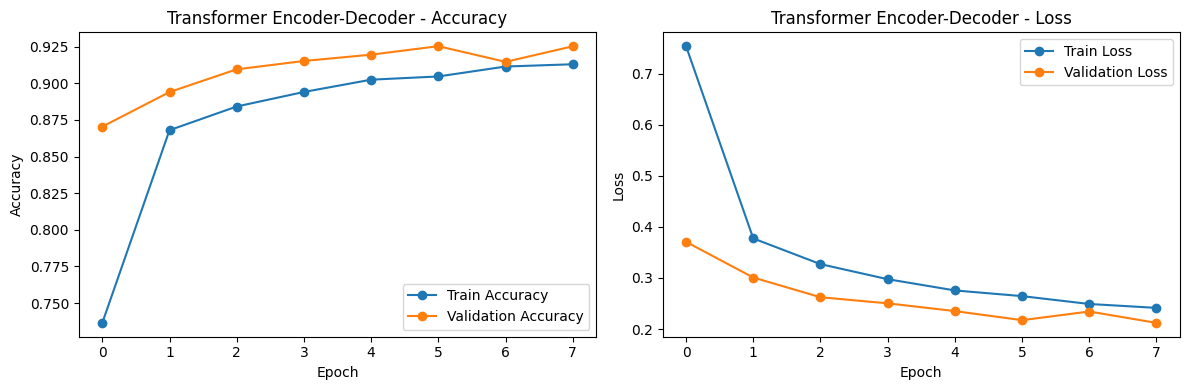

--- Transformer Encoder-Decoder Results ---
Accuracy: 0.9253
Macro F1: 0.9254
Trainable Params: 182,666


In [30]:
class TransformerEncoderDecoderClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, nhead=4,
                 num_enc_layers=2, num_dec_layers=1,
                 dim_feedforward=256, dropout=0.1,
                 num_classes=10, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout=dropout)

        # Encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        # enable_nested_tensor=False is required on MPS (Apple Silicon) to avoid
        # aten::_nested_tensor_from_mask_left_aligned which is not yet implemented there.
        self.encoder = nn.TransformerEncoder(
            enc_layer, num_layers=num_enc_layers,
            enable_nested_tensor=False, mask_check=False
        )

        # Decoder (single learnable CLS query)
        self.cls_query = nn.Parameter(torch.randn(1, 1, embed_dim))
        dec_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, lengths=None):
        batch_size = input_ids.size(0)

        # Padding mask for encoder
        if lengths is not None:
            seq_len = input_ids.size(1)
            time_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
            enc_key_mask = time_ids >= lengths.unsqueeze(1)  # (B, T) True=pad
        else:
            enc_key_mask = (input_ids == self.pad_idx)

        emb = self.pos_encoder(self.embedding(input_ids))        # (B, T, d)
        memory = self.encoder(emb, src_key_padding_mask=enc_key_mask)  # (B, T, d)

        # Expand CLS query for the batch
        query = self.cls_query.expand(batch_size, -1, -1)        # (B, 1, d)
        dec_out = self.decoder(query, memory,
                               memory_key_padding_mask=enc_key_mask)  # (B, 1, d)

        # Classify using the single decoder output token
        logits = self.classifier(dec_out[:, 0, :])               # (B, num_classes)
        return logits

model_transformer_encdec = TransformerEncoderDecoderClassifier(
    vocab_size=vocab_size, embed_dim=64, nhead=4,
    num_enc_layers=2, num_dec_layers=1,
    dim_feedforward=256, dropout=0.1,
    num_classes=num_classes, pad_idx=0
)
history_transformer_encdec = model_fit(model_transformer_encdec, train_loader, dev_loader, epochs=10, lr=0.001)
plot_accuracy(history_transformer_encdec, "Transformer Encoder-Decoder")
results.append(evaluate_model(model_transformer_encdec, dev_loader, "Transformer Encoder-Decoder"))

##### ***Final Comparison: Performance Summary***

The table below ranks all architectures by validation accuracy, providing a clear view of the performance gains achieved at each architectural step.

In [31]:
results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(results_sorted)

,Model,Accuracy,Macro F1,Parameters
0,Improved BiGRU,0.9923,0.992297,1702794
1,LSTM,0.9315,0.931709,91850
2,BiLSTM,0.9299,0.930207,176074
3,Transformer Encoder,0.9287,0.928537,115850
4,Transformer Encoder-Decoder,0.9253,0.925407,182666
5,Simple RNN Baseline,0.1027,0.025552,29642
